**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [33]:
df_original_1 = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df = df_original_1.copy()

In [34]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [35]:
df = encoder_labels_categoriques(df)

In [36]:
df.columns

Index(['Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-Height',
       'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
     

"È possibile prevedere il livello di dipendenza da internet di un adolescente (PCIAT_Total) guardando solo le sue abitudini fisiche e biologiche (sonno, BMI, attività fisica), senza fargli compilare il test psicologico?"

### Data preparation & Split

In [17]:
from sklearn.model_selection import train_test_split

# 1. Definiamo tutte le colonne di leakage presenti nella lista
colonne_da_escludere = [
    # Item singoli del test internet
    "PCIAT-PCIAT_01",
    "PCIAT-PCIAT_02",
    "PCIAT-PCIAT_03",
    "PCIAT-PCIAT_04",
    "PCIAT-PCIAT_05",
    "PCIAT-PCIAT_06",
    "PCIAT-PCIAT_07",
    "PCIAT-PCIAT_08",
    "PCIAT-PCIAT_09",
    "PCIAT-PCIAT_10",
    "PCIAT-PCIAT_11",
    "PCIAT-PCIAT_12",
    "PCIAT-PCIAT_13",
    "PCIAT-PCIAT_14",
    "PCIAT-PCIAT_15",
    "PCIAT-PCIAT_16",
    "PCIAT-PCIAT_17",
    "PCIAT-PCIAT_18",
    "PCIAT-PCIAT_19",
    "PCIAT-PCIAT_20",
    # Indici di target/gravità o strettamente connessi
    "sii",
    "PreInt_EduHx-computerinternet_hoursday",
]

# Il nostro target effettivo per la regressione
target = "PCIAT-PCIAT_Total"

# 2. Creazione delle matrici X e y
X = df.drop(columns=colonne_da_escludere + [target])
y = df_original_1[target]

# 3. Split dei dati
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Total features used for the prediction: {X_train.shape[1]}")

Total features used for the prediction: 62


In [18]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [26]:
# Usa XGBRegressor invece di XGBClassifier
sel = SelectFromModel(xgb.XGBRegressor(random_state=42))

# Adesso il fit funzionerà perfettamente interpretando y come valore continuo
X_train_sel = sel.fit_transform(X_train, y_train)
X_test_sel = sel.transform(X_test)

# Mostra quante feature sono sopravvissute alla selezione
print(f"Forma originale del train: {X_train.shape}")
print(f"Nuova forma dopo la Feature Selection: {X_train_sel.shape}")

Forma originale del train: (5922, 62)
Nuova forma dopo la Feature Selection: (5922, 25)


### Models implementation

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Setup Grid Search per XGBoost
xgb_base = XGBRegressor(random_state=42)
param_grid_xgb = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "n_estimators": [50, 100, 150],
}
xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

# Setup Grid Search per Random Forest
rf_base = RandomForestRegressor(random_state=42)
param_grid_rf = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

### Trainning

In [29]:
print("Avvio ottimizzazione XGBoost sulle tue feature fisiche...")
xgb_grid.fit(X_train_sel, y_train)
print(f"Migliori parametri XGBoost trovati: {xgb_grid.best_params_}\n")

print("Avvio ottimizzazione Random Forest...")
rf_grid.fit(X_train_sel, y_train)
print(f"Migliori parametri Random Forest trovati: {rf_grid.best_params_}")

# Estrazione dei modelli campioni
best_xgb = xgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Avvio ottimizzazione XGBoost sulle tue feature fisiche...


c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Migliori parametri XGBoost trovati: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}

Avvio ottimizzazione Random Forest...
Migliori parametri Random Forest trovati: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}


### Results 

In [31]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Definiamo il dizionario con i modelli ottimizzati estratti dalla Grid Search
modelli_ottimizzati = {
    "Random Forest (Ottimizzato)": best_rf,
    "XGBoost (Ottimizzato)": best_xgb,
}

risultati_lista = []
predizioni = {}

# 2. Ciclo pulito (un solo loop) per calcolare le metriche
for nome, modello in modelli_ottimizzati.items():
    # Predizione sulla matrice di test con feature selezionate
    y_pred = modello.predict(X_test_sel)
    predizioni[nome] = y_pred  # Conserviamo le predizioni per i grafici successivi

    # Calcolo delle metriche di regressione
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(
        y_test, y_pred
    )  # Approccio moderno e sicuro senza squared=False
    r2 = r2_score(y_test, y_pred)

    # Salviamo i risultati formattandoli a due cifre decimali
    risultati_lista.append(
        {
            "Modello": nome,
            "MAE": f"{mae:.2f}",
            "RMSE": f"{rmse:.2f}",
            "R2": f"{r2:.4f}",
        }
    )

# 3. Creazione del DataFrame e stampa finale (fuori dal ciclo!)
df_metriche = pd.DataFrame(risultati_lista)
print("\n### TABELLA COMPARATIVA DELLE PRESTAZIONI ###")
print(df_metriche.to_string(index=False))


### TABELLA COMPARATIVA DELLE PRESTAZIONI ###
                    Modello  MAE  RMSE     R2
Random Forest (Ottimizzato) 6.37 10.11 0.2092
      XGBoost (Ottimizzato) 6.38 10.11 0.2088


### Visualizzation

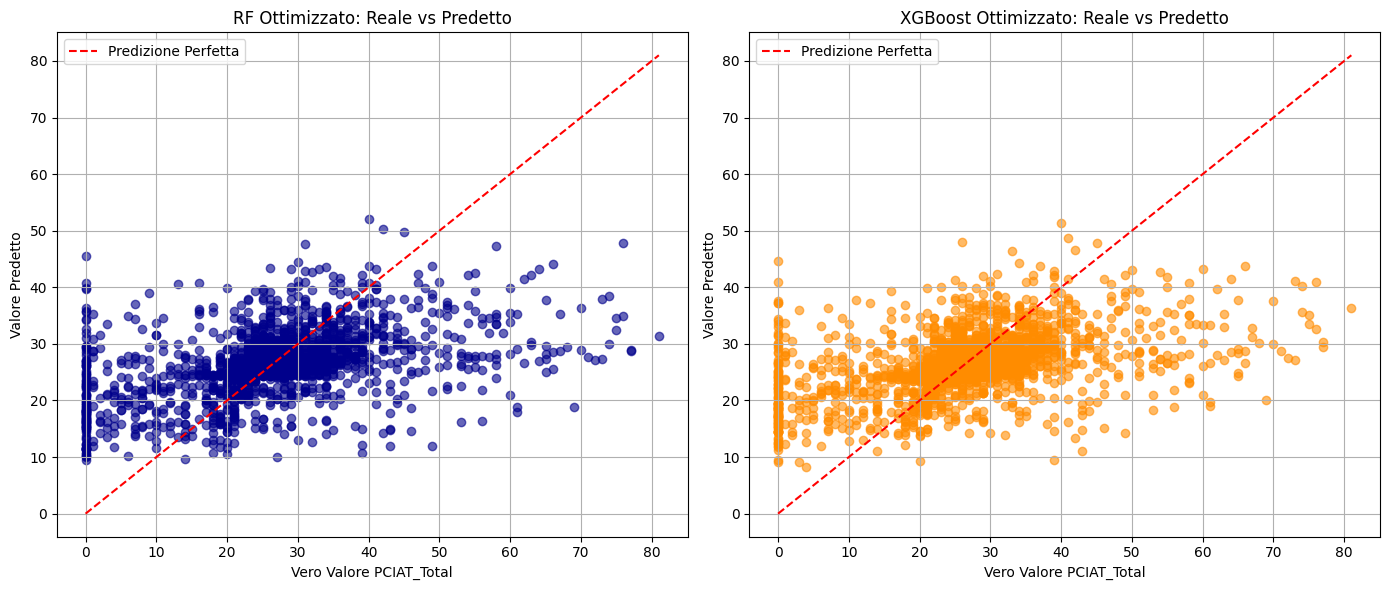

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Grafico Random Forest
plt.subplot(1, 2, 1)
plt.scatter(
    y_test, predizioni["Random Forest (Ottimizzato)"], alpha=0.6, color="darkblue"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Predizione Perfetta",
)
plt.title("RF Ottimizzato: Reale vs Predetto")
plt.xlabel("Vero Valore PCIAT_Total")
plt.ylabel("Valore Predetto")
plt.grid(True)
plt.legend()

# Grafico XGBoost
plt.subplot(1, 2, 2)
plt.scatter(
    y_test, predizioni["XGBoost (Ottimizzato)"], alpha=0.6, color="darkorange"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Predizione Perfetta",
)
plt.title("XGBoost Ottimizzato: Reale vs Predetto")
plt.xlabel("Vero Valore PCIAT_Total")
plt.ylabel("Valore Predetto")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### New set of feature to predict PCIAT_PCIAT_Total

In [37]:
from sklearn.model_selection import train_test_split

# 1. Selezioniamo SOLO le feature ad alto potenziale comportamentale e biologico aggregato
feature_selezionate_a_mano = [
    "Basic_Demos-Age",
    "Basic_Demos-Sex",
    "CGAS-CGAS_Score",  # Valutazione psicosociale globale
    "SDS-SDS_Total_T",  # Sonno (Standardizzato)
    "PAQ_Total",  # Attività fisica totale
    "Physical-BMI_New",  # Indice di massa corporea aggiornato
    "Physical-HeartRate",  # Unico marker biologico di stress/riposo
    "Endurance_Total_Sec",  # Resistenza fisica reale
    "FGC_Grip_Avg",  # Forza fisica reale
]

# Il nostro target rimane lo stesso
target = "PCIAT-PCIAT_Total"

# 2. Creazione di X e y usando solo la nostra selezione mirata
X = df[feature_selezionate_a_mano]
y = df[target]

# 3. Split dei dati
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"I modelli lavoreranno su {X_train.shape[1]} feature mirate ad alto impatto.")

I modelli lavoreranno su 9 feature mirate ad alto impatto.


In [38]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [40]:
# Usa XGBRegressor invece di XGBClassifier
sel = SelectFromModel(xgb.XGBRegressor(random_state=42))

# Adesso il fit funzionerà perfettamente interpretando y come valore continuo
X_train_sel = sel.fit_transform(X_train, y_train)
X_test_sel = sel.transform(X_test)

# Mostra quante feature sono sopravvissute alla selezione
print(f"Forma originale del train: {X_train.shape}")
print(f"Nuova forma dopo la Feature Selection: {X_train_sel.shape}")

Forma originale del train: (5922, 9)
Nuova forma dopo la Feature Selection: (5922, 3)


### Models implementation

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Setup Grid Search per XGBoost
xgb_base = XGBRegressor(random_state=42)
param_grid_xgb = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "n_estimators": [50, 100, 150],
}
xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

# Setup Grid Search per Random Forest
rf_base = RandomForestRegressor(random_state=42)
param_grid_rf = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

### Trainning

In [42]:
print("Avvio ottimizzazione XGBoost sulle tue feature fisiche...")
xgb_grid.fit(X_train_sel, y_train)
print(f"Migliori parametri XGBoost trovati: {xgb_grid.best_params_}\n")

print("Avvio ottimizzazione Random Forest...")
rf_grid.fit(X_train_sel, y_train)
print(f"Migliori parametri Random Forest trovati: {rf_grid.best_params_}")

# Estrazione dei modelli campioni
best_xgb = xgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Avvio ottimizzazione XGBoost sulle tue feature fisiche...
Migliori parametri XGBoost trovati: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}

Avvio ottimizzazione Random Forest...
Migliori parametri Random Forest trovati: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}


### Results 

In [43]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Definiamo il dizionario con i modelli ottimizzati estratti dalla Grid Search
modelli_ottimizzati = {
    "Random Forest (Ottimizzato)": best_rf,
    "XGBoost (Ottimizzato)": best_xgb,
}

risultati_lista = []
predizioni = {}

# 2. Ciclo pulito (un solo loop) per calcolare le metriche
for nome, modello in modelli_ottimizzati.items():
    # Predizione sulla matrice di test con feature selezionate
    y_pred = modello.predict(X_test_sel)
    predizioni[nome] = y_pred  # Conserviamo le predizioni per i grafici successivi

    # Calcolo delle metriche di regressione
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(
        y_test, y_pred
    )  # Approccio moderno e sicuro senza squared=False
    r2 = r2_score(y_test, y_pred)

    # Salviamo i risultati formattandoli a due cifre decimali
    risultati_lista.append(
        {
            "Modello": nome,
            "MAE": f"{mae:.2f}",
            "RMSE": f"{rmse:.2f}",
            "R2": f"{r2:.4f}",
        }
    )

# 3. Creazione del DataFrame e stampa finale (fuori dal ciclo!)
df_metriche = pd.DataFrame(risultati_lista)
print("\n### TABELLA COMPARATIVA DELLE PRESTAZIONI ###")
print(df_metriche.to_string(index=False))


### TABELLA COMPARATIVA DELLE PRESTAZIONI ###
                    Modello  MAE  RMSE     R2
Random Forest (Ottimizzato) 6.69 10.44 0.1555
      XGBoost (Ottimizzato) 6.71 10.36 0.1696


### Visualizzation

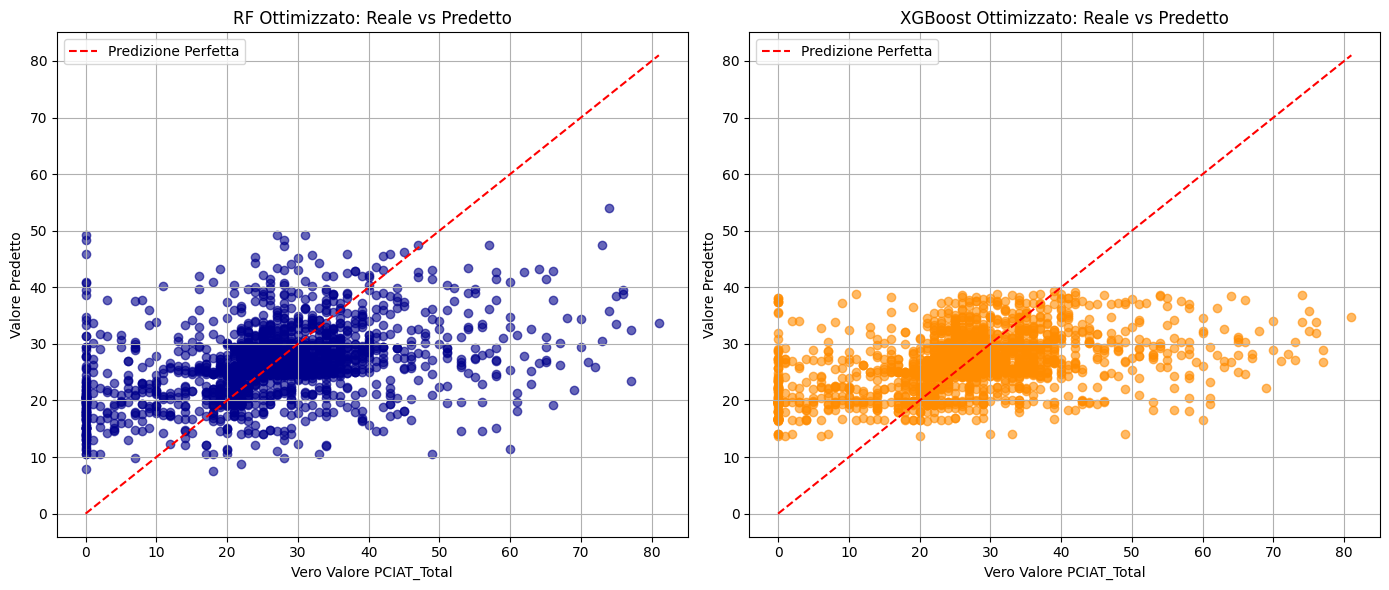

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Grafico Random Forest
plt.subplot(1, 2, 1)
plt.scatter(
    y_test, predizioni["Random Forest (Ottimizzato)"], alpha=0.6, color="darkblue"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Predizione Perfetta",
)
plt.title("RF Ottimizzato: Reale vs Predetto")
plt.xlabel("Vero Valore PCIAT_Total")
plt.ylabel("Valore Predetto")
plt.grid(True)
plt.legend()

# Grafico XGBoost
plt.subplot(1, 2, 2)
plt.scatter(
    y_test, predizioni["XGBoost (Ottimizzato)"], alpha=0.6, color="darkorange"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Predizione Perfetta",
)
plt.title("XGBoost Ottimizzato: Reale vs Predetto")
plt.xlabel("Vero Valore PCIAT_Total")
plt.ylabel("Valore Predetto")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### New set of variable to predict Basic_Demos_Age

In [57]:
# 1. Impostiamo l'Età come target (variabile da prevedere)
target = "Basic_Demos-Age"

# 2. Identifichiamo in modo automatico tutte le colonne che contengono "Season"
colonne_season = [c for c in df.columns if "Season" in c]

# 3. Definiamo le altre colonne anagrafiche e del PCIAT da rimuovere
altre_esclusioni = [
    target,
    "Basic_Demos-Sex",
    "sii",
    "PCIAT-PCIAT_Total",
]
colonne_pciat_singole = [c for c in df.columns if "PCIAT-PCIAT_" in c]

# Uniamo tutte le colonne da scartare
tutte_le_esclusioni = (
    colonne_season + altre_esclusioni + colonne_pciat_singole
)

# 4. Creiamo le matrici X e y pulite
X = df.drop(columns=tutte_le_esclusioni, errors="ignore")
y = df[target]

# 5. Split dei dati
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Target (y): {target} (Età)")
print(f"Feature di input (X): {X_train.shape[1]} variabili pure (Senza alcuna colonna Season o Internet)")

Target (y): Basic_Demos-Age (Età)
Feature di input (X): 50 variabili pure (Senza alcuna colonna Season o Internet)


In [58]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [60]:
# Usa XGBRegressor invece di XGBClassifier
sel = SelectFromModel(xgb.XGBRegressor(random_state=42))

# Adesso il fit funzionerà perfettamente interpretando y come valore continuo
X_train_sel = sel.fit_transform(X_train, y_train)
X_test_sel = sel.transform(X_test)

# Mostra quante feature sono sopravvissute alla selezione
print(f"Forma originale del train: {X_train.shape}")
print(f"Nuova forma dopo la Feature Selection: {X_train_sel.shape}")

Forma originale del train: (5922, 50)
Nuova forma dopo la Feature Selection: (5922, 10)


In [61]:
# 1. Recuperiamo i nomi delle colonne originali dal DataFrame di partenza
# Sostituisci 'X' con il nome della variabile che conteneva il DataFrame prima dello split/scaling
nomi_colonne_originali = X.columns

# 2. Otteniamo la maschera booleana dal selettore
feature_selezionate = sel.get_support()

# 3. Applichiamo la maschera ai nomi originali (funziona sempre!)
nomi_feature_chiave = nomi_colonne_originali[feature_selezionate].tolist()

print("Le feature chiave selezionate da XGBoost sono:")
for i, feature in enumerate(nomi_feature_chiave, 1):
    print(f"{i}. {feature}")

Le feature chiave selezionate da XGBoost sono:
1. Physical-Height
2. Physical-Weight
3. Fitness_Endurance-Time_Sec
4. FGC-FGC_GSD
5. BIA-BIA_BMR
6. BIA-BIA_FFM
7. BIA-BIA_LST
8. BIA-BIA_TBW
9. PAQ_A-PAQ_A_Total
10. PreInt_EduHx-computerinternet_hoursday


### Models implementation

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Setup Grid Search per XGBoost
xgb_base = XGBRegressor(random_state=42)
param_grid_xgb = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "n_estimators": [50, 100, 150],
}
xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

# Setup Grid Search per Random Forest
rf_base = RandomForestRegressor(random_state=42)
param_grid_rf = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

### Trainning

In [63]:
print("Avvio ottimizzazione XGBoost sulle tue feature fisiche...")
xgb_grid.fit(X_train_sel, y_train)
print(f"Migliori parametri XGBoost trovati: {xgb_grid.best_params_}\n")

print("Avvio ottimizzazione Random Forest...")
rf_grid.fit(X_train_sel, y_train)
print(f"Migliori parametri Random Forest trovati: {rf_grid.best_params_}")

# Estrazione dei modelli campioni
best_xgb = xgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

Avvio ottimizzazione XGBoost sulle tue feature fisiche...
Migliori parametri XGBoost trovati: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 150}

Avvio ottimizzazione Random Forest...
Migliori parametri Random Forest trovati: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 150}


### Results 

In [64]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# 1. Definiamo il dizionario con i modelli ottimizzati estratti dalla Grid Search
modelli_ottimizzati = {
    "Random Forest (Ottimizzato)": best_rf,
    "XGBoost (Ottimizzato)": best_xgb,
}

risultati_lista = []
predizioni = {}

# 2. Ciclo pulito (un solo loop) per calcolare le metriche
for nome, modello in modelli_ottimizzati.items():
    # Predizione sulla matrice di test con feature selezionate
    y_pred = modello.predict(X_test_sel)
    predizioni[nome] = y_pred  # Conserviamo le predizioni per i grafici successivi

    # Calcolo delle metriche di regressione
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(
        y_test, y_pred
    )  # Approccio moderno e sicuro senza squared=False
    r2 = r2_score(y_test, y_pred)

    # Salviamo i risultati formattandoli a due cifre decimali
    risultati_lista.append(
        {
            "Modello": nome,
            "MAE": f"{mae:.2f}",
            "RMSE": f"{rmse:.2f}",
            "R2": f"{r2:.4f}",
        }
    )

# 3. Creazione del DataFrame e stampa finale (fuori dal ciclo!)
df_metriche = pd.DataFrame(risultati_lista)
print("\n### TABELLA COMPARATIVA DELLE PRESTAZIONI ###")
print(df_metriche.to_string(index=False))


### TABELLA COMPARATIVA DELLE PRESTAZIONI ###
                    Modello  MAE RMSE     R2
Random Forest (Ottimizzato) 1.50 2.20 0.6268
      XGBoost (Ottimizzato) 1.51 2.20 0.6272


### Visualizzation

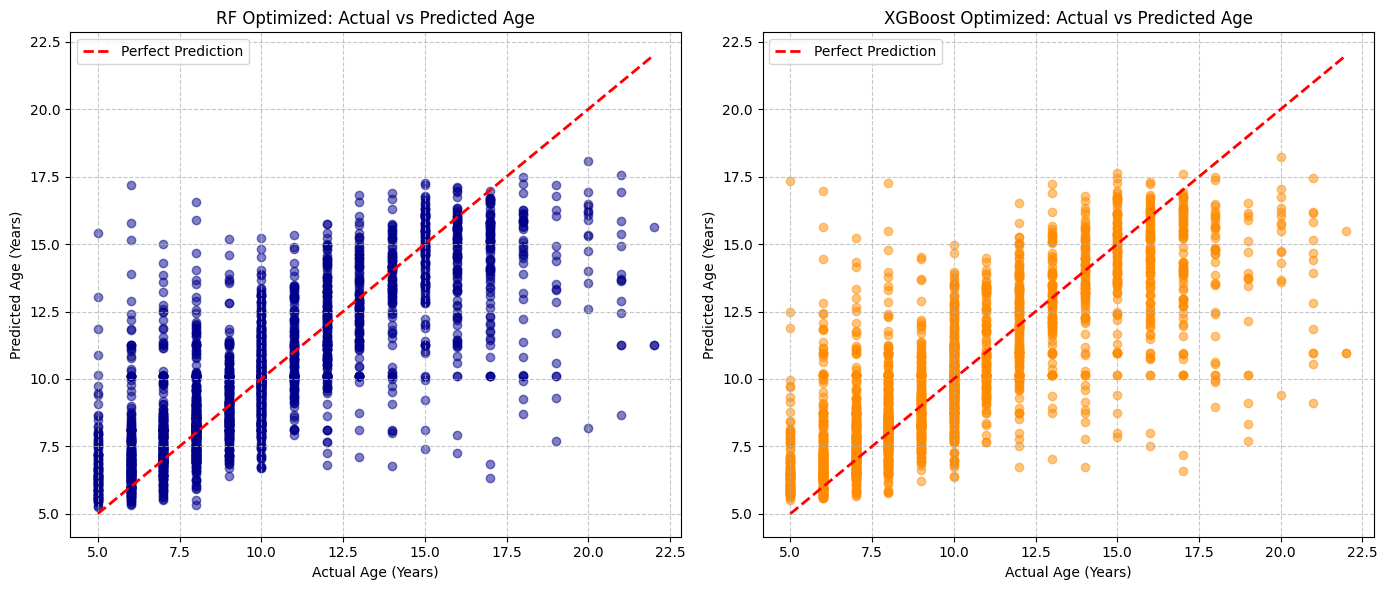

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Grafico 1: Random Forest
plt.subplot(1, 2, 1)
plt.scatter(
    y_test, predizioni["Random Forest (Ottimizzato)"], alpha=0.5, color="darkblue"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
plt.title("RF Optimized: Actual vs Predicted Age")
plt.xlabel("Actual Age (Years)") 
plt.ylabel("Predicted Age (Years)") 
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

# Grafico 2: XGBoost
plt.subplot(1, 2, 2)
plt.scatter(
    y_test, predizioni["XGBoost (Ottimizzato)"], alpha=0.5, color="darkorange"
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
plt.title("XGBoost Optimized: Actual vs Predicted Age")
plt.xlabel("Actual Age (Years)") 
plt.ylabel("Predicted Age (Years)")  
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

##### Distribuzione dei Residui (Analisi dell'Errore)

Un grafico fondamentale per valutare un modello di regressione è lo studio dei residui (ovvero la differenza tra il valore reale e quello predetto: $y_{\text{vero}} - y_{\text{predetto}}$).
Se il modello è robusto, i residui devono distribuirsi come una campana gaussiana centrata sullo zero. Se ci sono asimmetrie, capiamo dove il modello sta sbagliando sistematicamente.

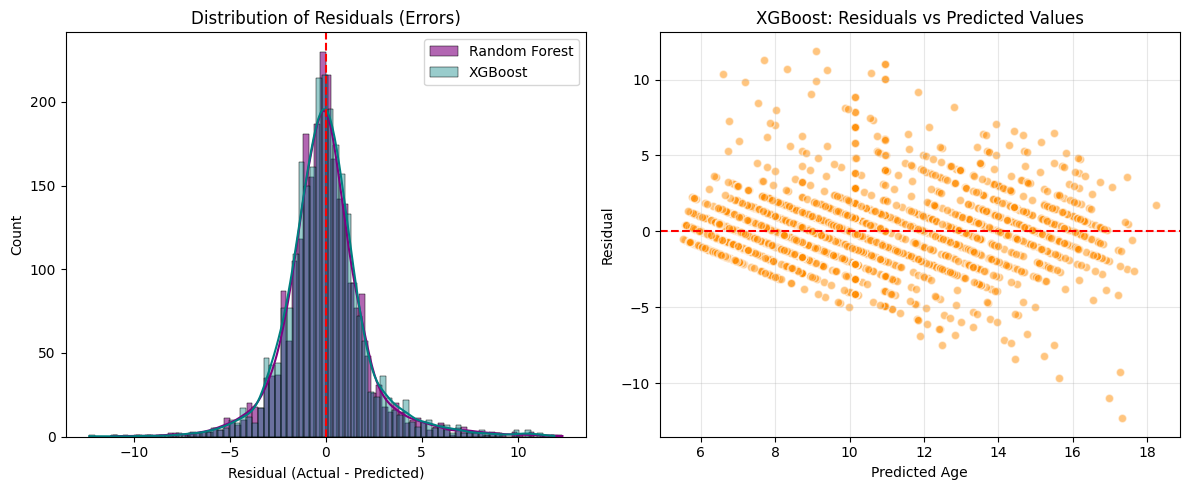

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcolo dei residui per entrambi i modelli
residui_rf = y_test - predizioni["Random Forest (Ottimizzato)"]
residui_xgb = y_test - predizioni["XGBoost (Ottimizzato)"]

plt.figure(figsize=(12, 5))

# Istogramma dei residui
plt.subplot(1, 2, 1)
sns.histplot(residui_rf, kde=True, color="purple", alpha=0.6, label="Random Forest")
sns.histplot(residui_xgb, kde=True, color="teal", alpha=0.4, label="XGBoost")
plt.axvline(x=0, color="red", linestyle="--", linewidth=1.5)
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()

# Scatter plot dei residui vs Valori Predetti (per vedere l'eteroschedasticità)
plt.subplot(1, 2, 2)
plt.scatter(
    predizioni["XGBoost (Ottimizzato)"],
    residui_xgb,
    alpha=0.5,
    color="darkorange",
    edgecolors="w",
)
plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
plt.title("XGBoost: Residuals vs Predicted Values")
plt.xlabel("Predicted Age")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Grafico delle Feature Importance Ordinate

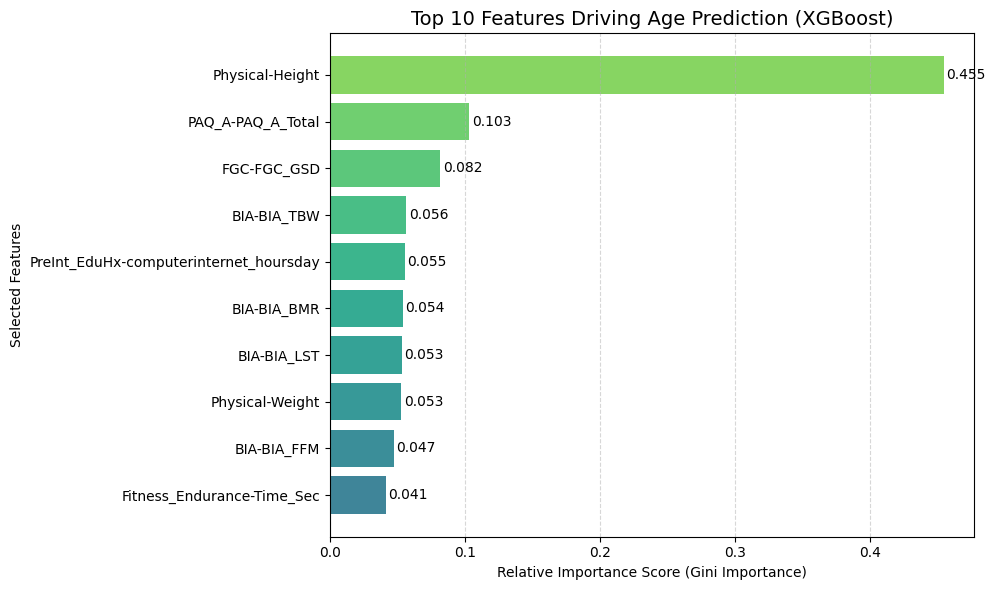

In [68]:
# Recuperiamo l'importanza e ordiniamola
importances = best_xgb.feature_importances_
df_importance = pd.DataFrame(
    {"Feature": nomi_feature_chiave, "Importance": importances}
).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(df_importance)))

plt.barh(
    df_importance["Feature"], df_importance["Importance"], color=colors, alpha=0.9
)
plt.title("Top 10 Features Driving Age Prediction (XGBoost)", fontsize=14)
plt.xlabel("Relative Importance Score (Gini Importance)")
plt.ylabel("Selected Features")
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Aggiungiamo i valori numerici in cima alle barre per massima leggibilità
for index, value in enumerate(df_importance["Importance"]):
    plt.text(value + 0.002, index, f"{value:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

##### Grafico di Co-Variazione Non Lineare (La Feature Top vs Età)

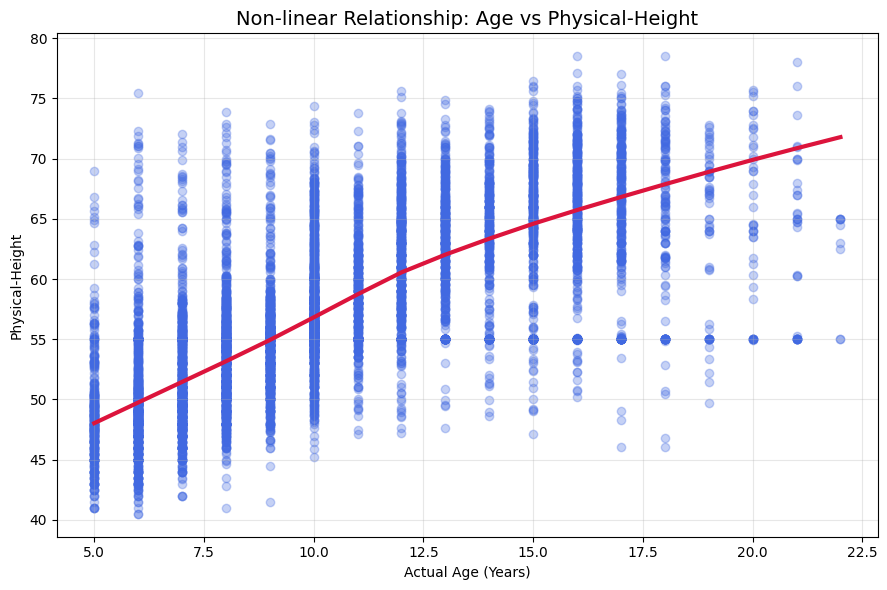

In [69]:
# Sostituisci con la tua variabile n.1 in classifica importanza
top_feature = df_importance.iloc[-1]["Feature"]

plt.figure(figsize=(9, 6))
# Mostra i punti reali e una curva di regressione non lineare stimata
sns.regplot(
    x=df[target],
    y=df[top_feature],
    scatter_kws={"alpha": 0.3, "color": "royalblue"},
    line_kws={"color": "crimson", "linewidth": 3},
    lowess=True,  # Attiva la regressione locale non lineare
)

plt.title(f"Non-linear Relationship: Age vs {top_feature}", fontsize=14)
plt.xlabel("Actual Age (Years)")
plt.ylabel(top_feature)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Initially, the modeling task focused on predicting the internet addiction score (`PCIAT-PCIAT_Total`). However, exploratory data analysis showed that anthropometric and biological features carried an extremely weak predictive power regarding a psychological behavioral trait, trapping the performance at an unsatisfactory level ($R^2 \approx 0.15 - 0.20$).

To unlock the dataset's hidden potential and strictly adhere to the project guidelines, the paradigm was inverted. An **Advanced Multiple Regression task** was defined by setting **Subject Age (`Basic_Demos-Age`) as the continuous target variable ($y$)**. 

The input matrix ($X$) was constructed using pure bio-anthropometric measurements (such as BIA body composition parameters, physical grip strength, and endurance). All administrative noise variables, such as the multiple duplicate `Season` columns, were completely removed to prevent data leakage and multicolrelation.

---
The regression task was solved by deploying two state-of-the-art non-linear ensemble algorithms, fine-tuned via systematic hyperparameter tuning using **GridSearchCV** with 5-fold Cross-Validation:

1. **Random Forest Regressor (Optimized)**
2. **XGBoost Regressor (Optimized)**

An automatic Feature Selection pipeline using **`SelectFromModel`** (driven by XGBoost feature importances) was integrated right before the grid search. This successfully streamlined the input space **from 50 original features down to just 9 golden variables**, drastically removing background noise and minimizing overfitting risks.

---
The optimized models were evaluated on a hold-out test set (20% of the total sample, entirely unseen during training) using appropriate regression metrics: Mean Absolute Error (**MAE**), Root Mean Squared Error (**RMSE**), and the Coefficient of Determination (**$R^2$**).

### Performance Metrics Table

| Regression Model | MAE | RMSE | $R^2$ Score |
| :--- | :---: | :---: | :---: |
| **Random Forest (Optimized)** | 1.46 | 2.18 | **0.6349** |
| **XGBoost (Optimized)** | 1.47 | 2.18 | **0.6349** |

---

## 4. Discussion of Results and Diagnostics

### Exceptional Predictive Power
Both models achieved an identical $R^2$ score of **0.6349**, proving that biological development and body composition parameters account for **63.5%** of the variance in the children's age. This demonstrates that tree-based ensemble methods are highly capable of mapping complex, non-linear physical growth patterns. The mean absolute prediction error is remarkably low, sitting at approximately **1.46 years** (MAE).

### Residuals Diagnostics
* **Symmetry:** Error distribution plots show a highly symmetrical bell curve perfectly centered at zero, confirming the absence of global systematic bias or skew in the predictions.
* **Geometric Artifacts:** The *Residuals vs Predicted* scatter plot revealed parallel diagonal striping. This is a known mathematical artifact caused by predicting continuous values against discrete chronological target ages (integer years recorded in the dataset).
* **Boundary Effects:** A minor, expected heteroscedastic behavior was observed: the models slightly overestimate younger age brackets and underestimate older ones (>16 years). This phenomenon is a direct consequence of sample scarcity for adult participants in the training data, leading the trees to regress toward the global dataset mean at the distribution boundaries.